The purpose of this file is to perform analysis on test_31-test60 (sample duration variance)

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [106]:
durations = [90 + 30*i for i in range(18)]
data = []
for duration in durations:
   sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(1,3)])
   data.append(np.array([sheet[f"Channel {i}"] for i in range(3)]))
# There was an issue with test_39, so we can't convert to a numpy array (inhomogenous shape)
# data = np.array(data)
print(len(data))
for i in range(len(data)): print(len(data[i]),end=', ')
print()
for i in range(len(data[0])): print(len(data[0][i]),end=', ')
print()
for i in range(len(data[1])): print(len(data[1][i]),end=', ')

18
3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 
730, 730, 730, 
570, 570, 570, 

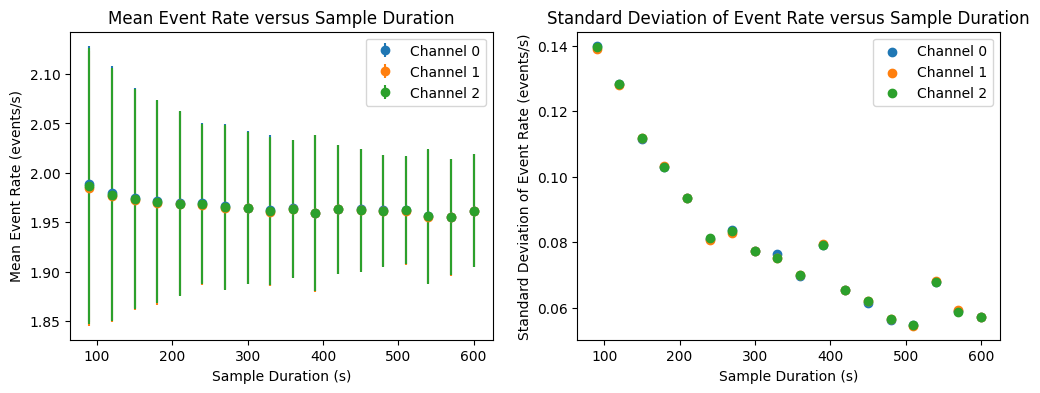

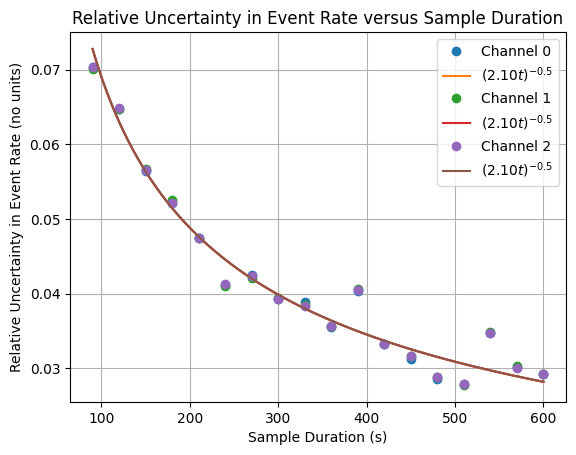

In [107]:
def get_mean_and_std(data, ch, idx, durations, pm = True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx::5]
      # print(subset)
      # print()
      if pm:
         subset = np.array([np.array(er.split(" ± "),dtype=np.float64)[0] for er in subset])
      # print(subset)
      # print()
      output.append([np.mean(subset),np.std(subset)])
   return output

def f(x,m,b):
   return m * x + b

def g(x,b):
   return 1 / np.sqrt(x * b)

fig, axs = plt.subplots(1,2,figsize=(12,4))
axs[1].set_title("Standard Deviation of Event Rate versus Sample Duration")
axs[1].set_xlabel("Sample Duration (s)")
axs[1].set_ylabel("Standard Deviation of Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[1].scatter(durations,[pair[1] for pair in event_rate],label=f"Channel {ch}")
axs[1].legend()

axs[0].set_title("Mean Event Rate versus Sample Duration")
axs[0].set_xlabel("Sample Duration (s)")
axs[0].set_ylabel("Mean Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[0].errorbar(durations,[pair[0] for pair in event_rate],yerr=[pair[1] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
axs[0].legend()
plt.show()

x = np.linspace(np.min(durations),np.max(durations),1000)
plt.title("Relative Uncertainty in Event Rate versus Sample Duration")
plt.xlabel("Sample Duration (s)")
plt.ylabel("Relative Uncertainty in Event Rate (no units)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in event_rate],p0=[1.99])
   plt.plot(durations,[pair[1]/pair[0] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
   plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

In [108]:
langaus_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="LanGauss Height") for i in range(1,3)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['c'], ch['mu'], ch['mean'], ch['std'], ch['0.10% Threshold']])
      dur_data.append(ch_stats)
   langaus_data.append(dur_data)

print(len(langaus_data))
print(len(langaus_data[0]))
print(len(langaus_data[0][0]))
print(len(langaus_data[0][0][0]))
print(langaus_data[0][0][0])

18
4
6
146
[2.34008089e+00 1.07482904e+00 3.04708663e+00 1.40293280e+00
 9.17784114e+00 1.19118680e+00 1.26611057e+00 1.24846418e+00
 3.30674134e+00 1.74257214e+00 2.38050348e+00 7.22939507e-01
 2.47851759e+00 1.85137112e+00 1.59363961e+00 2.16203925e+00
 1.01227584e+00 1.51181555e+00 1.49755708e+00 1.84092218e+00
 1.07649554e+00 1.93119861e+00 9.63695318e+00 2.13620875e+00
 1.08627772e+00 1.86105844e+00 1.54168773e+00 1.16079332e+00
 1.18280138e+00 1.39219148e+00 1.05686827e+00 1.10600249e+00
 1.06820132e+00 2.26791139e+00 1.58403457e+00 1.22921855e+00
 1.49380411e+00 1.15450193e+00 1.93110300e+00 1.21842115e+00
 9.61084155e-01 1.62431388e+00 1.03451356e+00 1.12957435e+00
 9.99290556e-01 1.71676188e+00 3.72839463e+00 1.03055618e+00
 3.81606011e+00 1.62748393e+00 1.10617533e+00 1.86000385e+00
 1.52551012e+00 1.43001648e+00 1.24127564e+00 1.25746083e+00
 1.17572229e+00 3.28018710e+00 1.64430291e+00 1.88256174e+00
 1.68048012e+00 2.13540887e+00 5.87484260e+02 1.17960418e+00
 1.68538447e+

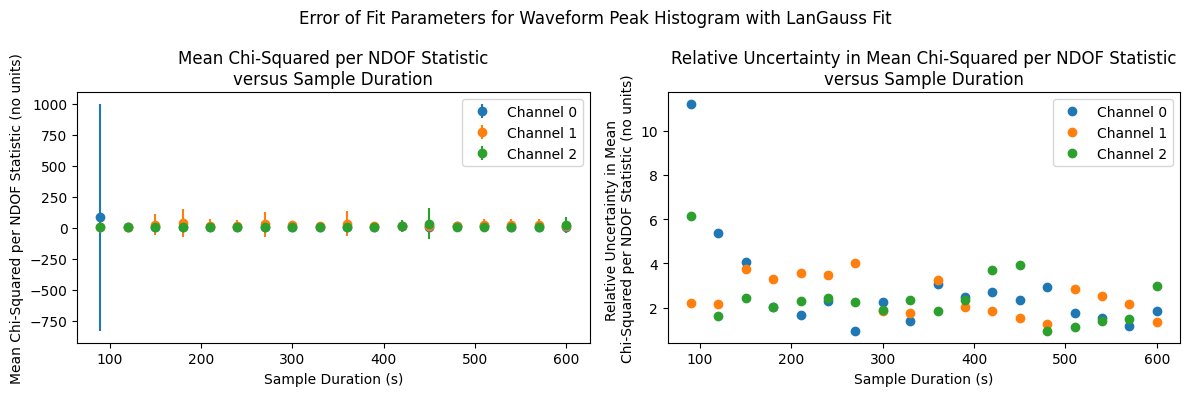

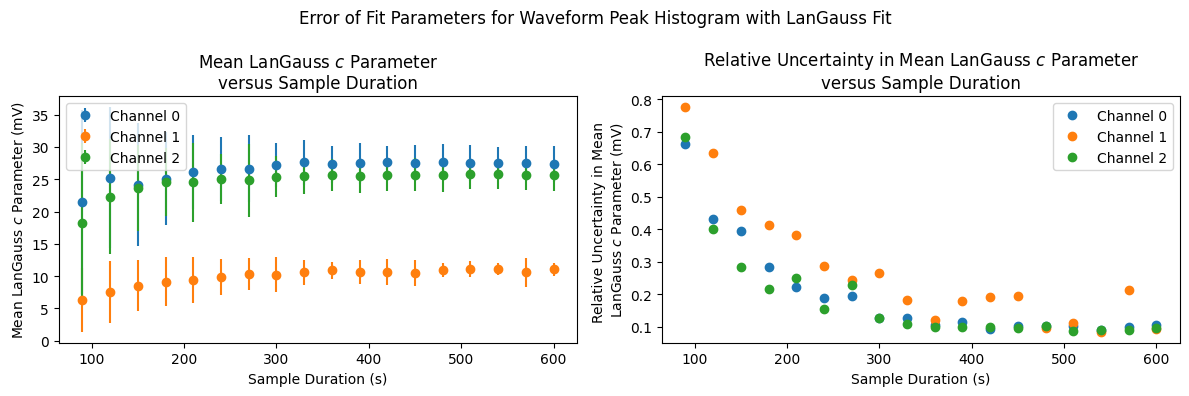

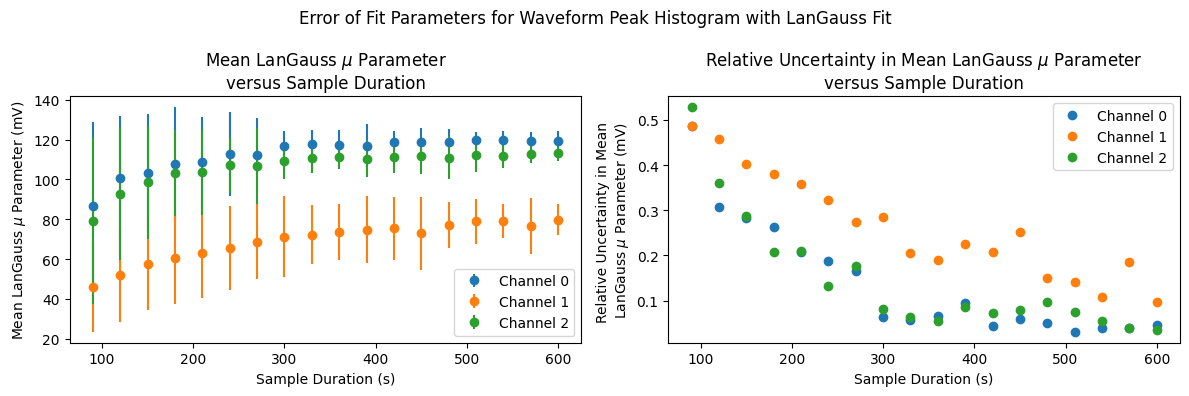

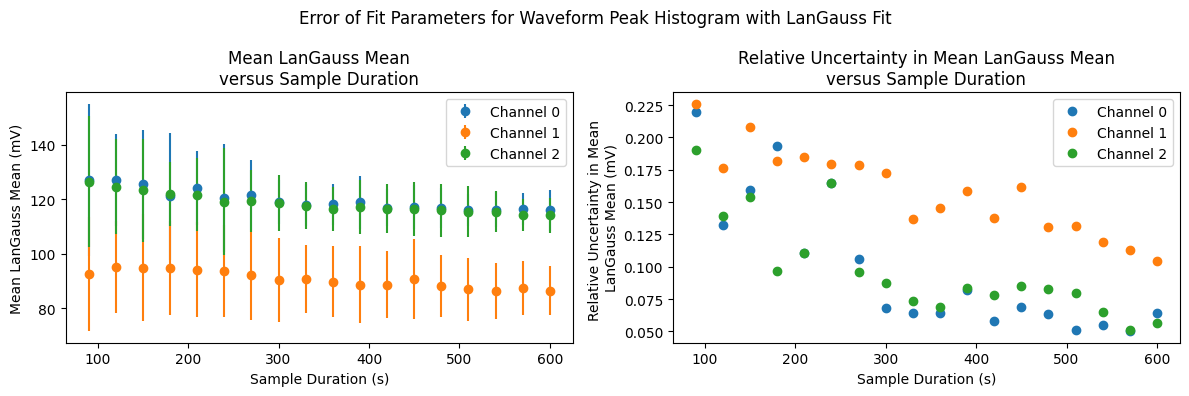

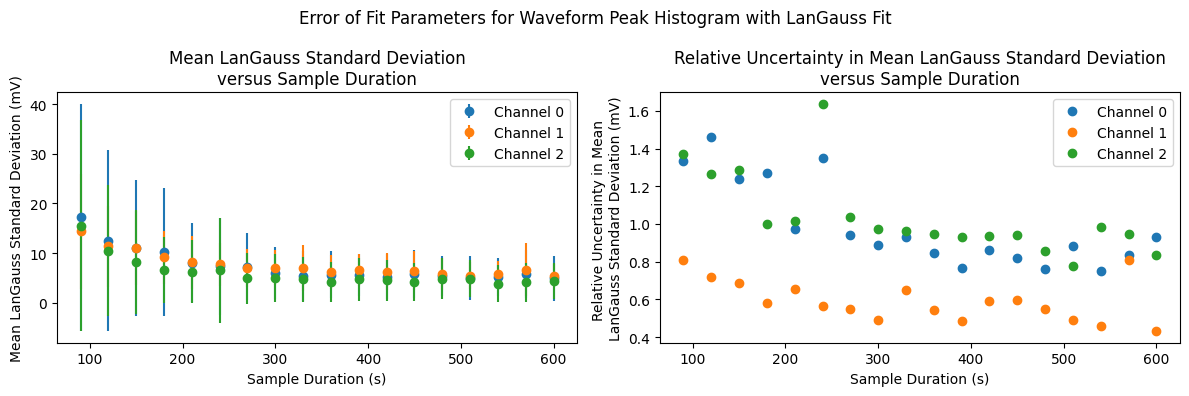

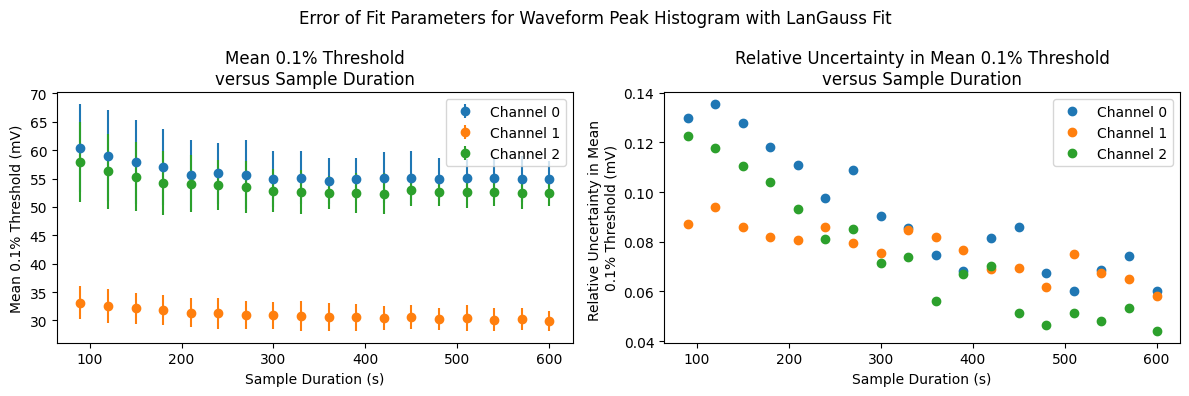

In [119]:
def get_mean_and_std2(data, ch, idx, durations, pm = True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx]
      output.append([np.mean(subset),np.std(subset)])
   return output

stats = ['Chi-Squared per NDOF Statistic', 'LanGauss $c$ Parameter', r'LanGauss $\mu$ Parameter', 'LanGauss Mean', 'LanGauss Standard Deviation','0.1% Threshold']
units = ['no units', 'mV', 'mV', 'mV', 'mV', 'mV']
p0_f=[1.2,-0.0004]
p0_g=[2,]

for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Waveform Peak Histogram with LanGauss Fit")
   axs[1].set_title("Relative Uncertainty in Mean "+ stats[j] + "\nversus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty in Mean \n"+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()



In [114]:
energy_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(1,3)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['K'], ch['mean'], ch['std']])
      dur_data.append(ch_stats)
   energy_data.append(dur_data)

print(len(energy_data))
print(len(energy_data[0]))
print(len(energy_data[0][0]))
print(len(energy_data[0][0][0]))
print(energy_data[0][0][0])

18
4
4
146
[7.82842405e-01 1.50103653e+00 9.65475153e-01 1.25027287e+00
 6.44486099e-01 1.01929873e+00 1.54517877e+00 9.00998944e-01
 3.18610670e+00 1.05470507e+00 1.65861471e+00 2.77053048e-01
 4.01160432e+00 2.89026989e+00 6.29931311e-01 1.06763091e+00
 3.94234303e-01 2.13943936e+00 1.11737628e+00 1.28052058e+02
 8.00875966e-01 2.10137401e+00 5.95423453e+00 2.03979528e+00
 5.76574294e-01 6.01325455e+00 1.48032337e+00 2.56631584e+00
 8.07537978e-01 6.07454898e-01 7.62546179e-01 8.55034943e-01
 6.13002417e-01 3.34812887e+02 7.12490496e+01 9.74444107e-01
 3.24691219e+00 1.38395956e+00 1.45732842e+00 1.29281610e+00
 9.20699253e-01 1.01755222e+00 5.81135099e-01 8.73651084e+00
 1.45129241e+00 1.21886572e+00 9.45802716e+01 6.09452191e-01
 2.43775324e+00 2.80868134e+01 4.79117774e-01 9.71088133e-01
 1.91033758e+00 9.55649623e-01 6.82773205e-01 6.05075326e-01
 9.66307920e-01 9.84492482e-01 1.64281089e+00 1.24212436e+00
 6.44995418e-01 8.45864000e-01 3.54902516e+00 1.40960704e+00
 8.81892191e-

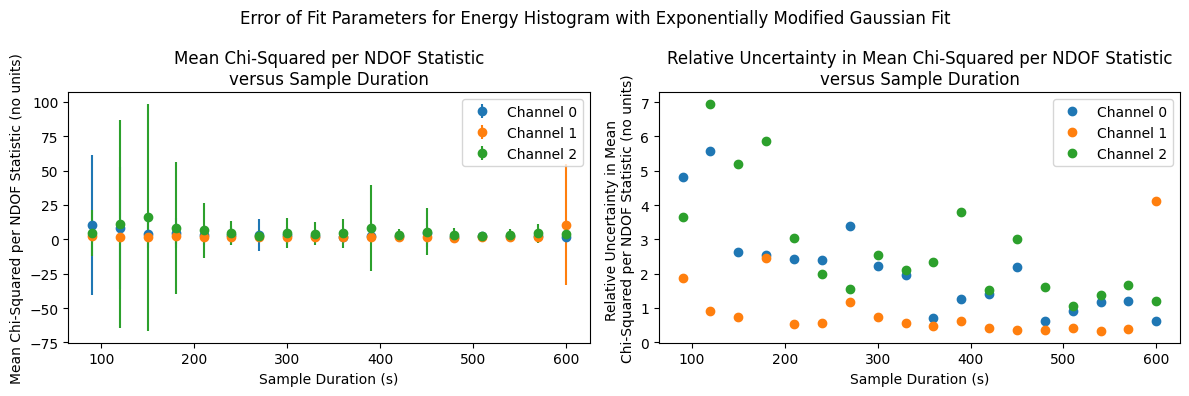

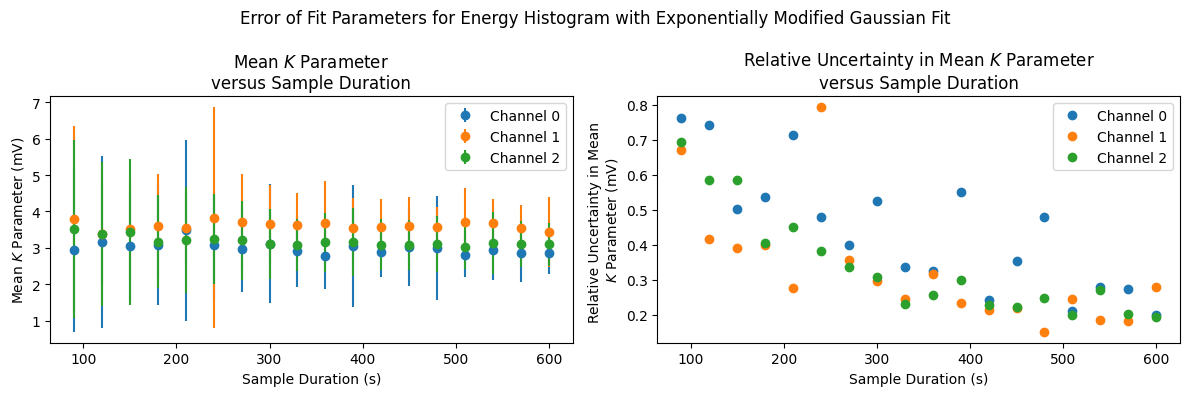

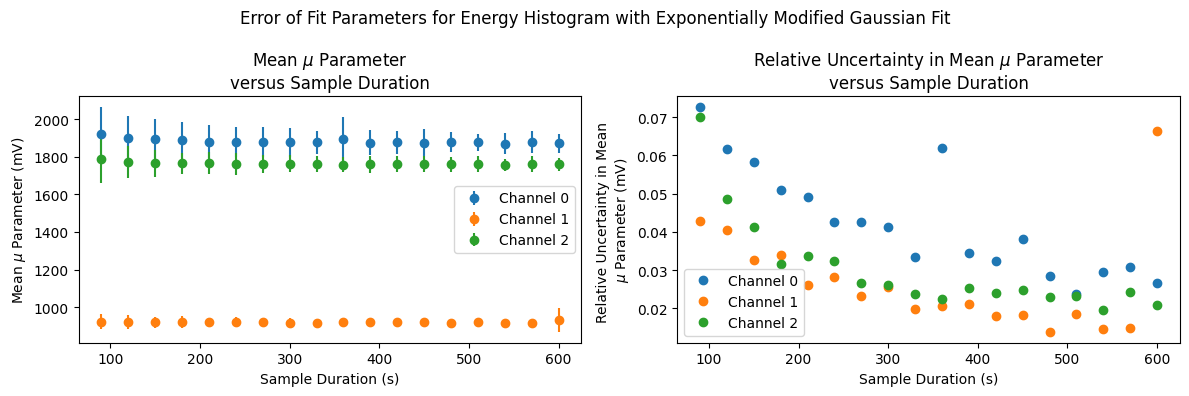

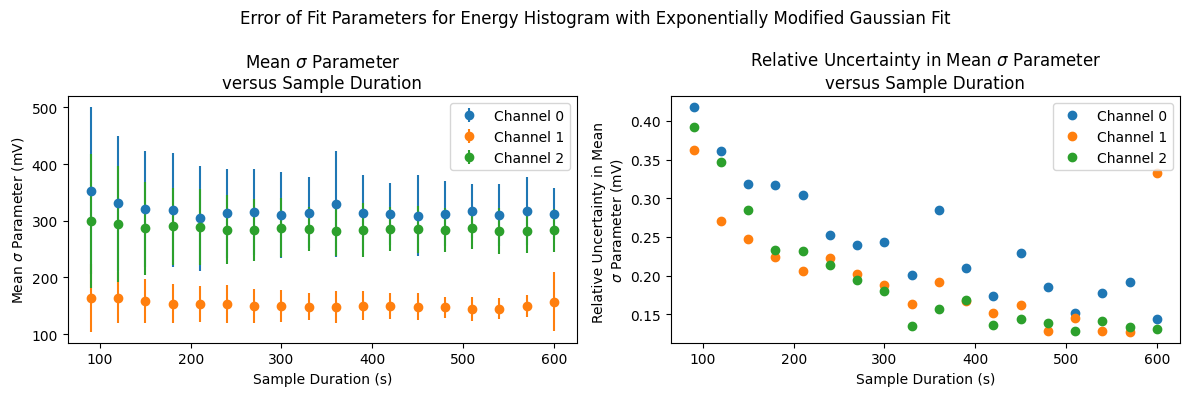

In [120]:
stats = ['Chi-Squared per NDOF Statistic', '$K$ Parameter', r'$\mu$ Parameter', r'$\sigma$ Parameter']
units = ['no units', 'mV', 'mV', 'mV', 'mV', 'mV']
for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Energy Histogram with Exponentially Modified Gaussian Fit")
   axs[1].set_title("Relative Uncertainty in Mean "+ stats[j] + "\nversus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty in Mean \n" + stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      # prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()